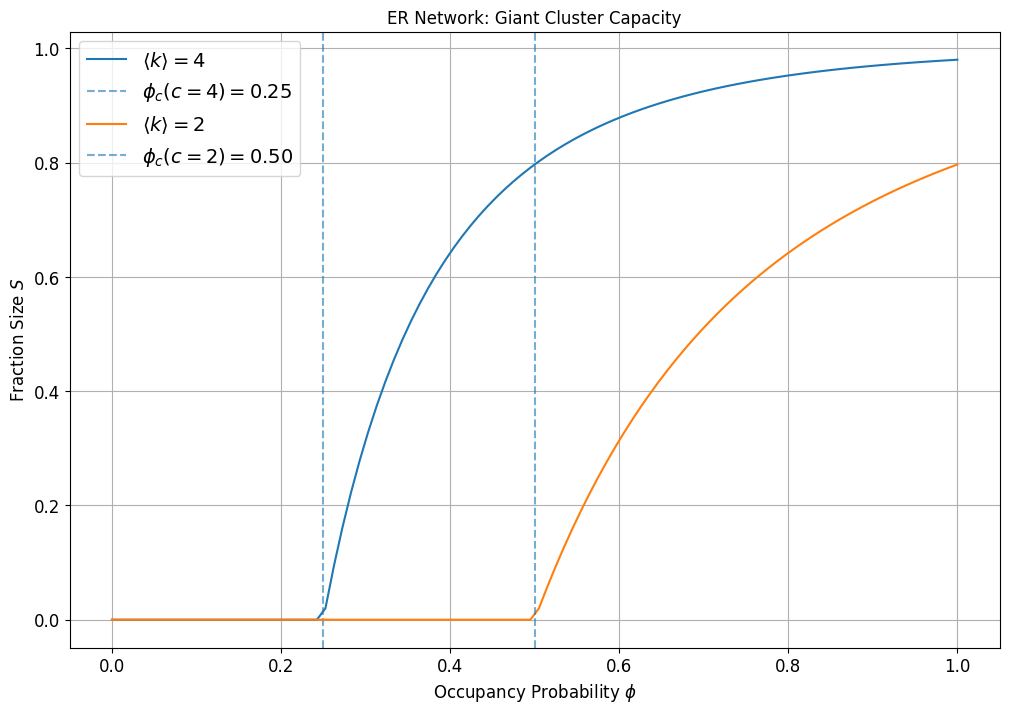

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# =========================================================
# Part (a): Bond percolation on an ER network
# =========================================================
def solve_ER_percolation(c_values):
    phi_vals = np.linspace(0, 1, 100)
    plt.figure(figsize=(12, 8))
    
    for c in c_values:
        S_vals = []
        for phi in phi_vals:
            # Objective: solve u = 1 - phi + phi * exp(c(u - 1))
            # f(u) = u - (1 - phi + phi * exp(c * (u - 1)))
            func = lambda u: u - (1 - phi + phi * np.exp(c * (u - 1)))
            
            # Start search near 0 to reliably locate a valid underlying non-trivial root
            u_sol = fsolve(func, 0.0)[0]
            
            # Size of GC is S = 1 - g_0(u)
            S = 1 - np.exp(c * (u_sol - 1))
            S_vals.append(max(0, S)) # Ensure noise is cleaned
            
        plt.plot(phi_vals, S_vals, label=f'$\\langle k \\rangle = {c}$')
        
        # Display phi_c vertical marker
        phi_c = 1.0 / c
        plt.axvline(phi_c, linestyle='--', alpha=0.6, 
                    label=f'$\\phi_c (c={c}) = {phi_c:.2f}$')

    plt.title('ER Network: Giant Cluster Capacity', fontsize=12)
    plt.xlabel('Occupancy Probability $\\phi$', fontsize=12)
    plt.xticks(fontsize=12)
    plt.ylabel('Fraction Size $S$', fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.show()

# Execute plot generator for c=4 and c=2 parameter limits
solve_ER_percolation([4, 2])